# **Step1. 상품 리뷰 감성 분류**

**미션 : 리뷰마다 긍/부정 감성분석하기**
1) 목표 : 리뷰를 긍, 부정으로 분류하는 모델 생성
사전학습 모델을 파인 튜닝하여 모델 성능 높이기
2) 절차
    * 데이터 전처리
        - 긍/부정 분류를 위한 데이터셋 구성
        - 데이터 불균형 문제 해결하기
    * 사전학습 모델 파인 튜닝 : klue/bert-base 사용 권장
3) 최소 4가지 이상의 실험을 구성하고 수행하고 성능 비교
    * 학습 + 검증 데이터 : 10만 건 중 일부를 샘플링해서 수행.
    * 모델링 : 일반 파인튜닝, LoRA 파인튜닝 적용
    * 하이퍼파라미터 조정


## 1.환경준비

### (1) 라이브러리 설치 및 로딩

In [8]:
!pip install datasets peft accelerate -q

* 설치 후 세션 다시 시작

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
from datasets import load_dataset, Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import LabelEncoder

from peft import get_peft_model, LoraConfig, TaskType

from warnings import filterwarnings
FutureWarning
filterwarnings('ignore')

In [ ]:
# (Colab) 시각화 한글폰트 설정을 위해 아래 코드를 실행하세요.
!apt -qq -y install fonts-nanum > /dev/null
!rm -rf ~/.cache/matplotlib

import matplotlib as mpl
import matplotlib.font_manager as fm
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
mpl.rcParams['font.family'] = 'NanumGothic'
mpl.rcParams['axes.unicode_minus'] = False

* 함수 생성

In [10]:
# 검증셋 평가 함수
def evaluate(val_ds, model, device, tokenizer):
    # 입력 데이터셋 토크나이징 (attention_mask 포함)
    inputs = tokenizer(list(val_ds['text']), return_tensors="pt", padding=True,
                       truncation=True, max_length=128
    )
    inputs = {key: value.to(device) for key, value in inputs.items()}  # 입력 텐서를 동일한 디바이스로 이동

    # 모델을 지정된 디바이스로 이동
    model = model.to(device)

    with torch.no_grad():  # 평가 과정에서 기울기 계산 비활성화
        outputs = model(**inputs)  # attention_mask를 포함해 입력

    # 예측 및 확률 계산
    probabilities = outputs.logits.softmax(dim=1)

    # probabilities가 GPU에 있을 경우에만 CPU로 이동
    if probabilities.is_cuda:
        probabilities = probabilities.cpu().detach().numpy()
    else:
        probabilities = probabilities.detach().numpy()

    pred = np.argmax(probabilities, axis=1)

    # GPU 메모리에서 필요 없는 텐서 제거 및 캐시 정리
    del inputs
    torch.cuda.empty_cache()

    return pred, probabilities

In [11]:
def predict(text, model, tokenizer):
    # 모델을 CPU로 이동
    model = model.to("cpu")

    # 입력 문장 토크나이징 → CPU 텐서로 생성
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)

    # 모델 예측 (no_grad로 메모리 절약)
    with torch.no_grad():
        outputs = model(**inputs)

    # 확률 계산
    logits = outputs.logits
    probabilities = torch.softmax(logits, dim=1)

    # 예측 클래스
    pred = torch.argmax(probabilities, dim=-1).item()

    return pred, probabilities


### (2) GPU 설정
* GPU 사용을 위한 설정

In [12]:
# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## 2.데이터 준비① : 데이터 구조 만들기
* 아래와 같은 형태로 데이터 셋을 준비합니다.
    * 하나의 리뷰 문장에 하나의 긍/부정 값 지정
    * 리뷰별 label의 평균 값 >= 0.5 ➔ 긍정(1)

* 데이터 불균형을 확인하고 조치합니다.

### (1) 데이터 불러오기
* 제공 받은 'data.csv' 파일을 불러 옵니다.

In [7]:
# 파일 업로드
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


In [13]:
df = pd.read_csv('data.csv')

In [14]:
df.head()

,text,aspect,label
0,유통기한도 넉넉하고 구성도 많아서 선물 하기 좋네요. 만족합니다.,포장,1
1,유통기한도 넉넉하고 구성도 많아서 선물 하기 좋네요. 만족합니다.,품질,1
2,스틱 제형이라 바르기 좋고 보습력도 좋아요. 무엇보다 손에 안 묻히고 바를 수 있어...,보습,1
3,스틱 제형이라 바르기 좋고 보습력도 좋아요. 무엇보다 손에 안 묻히고 바를 수 있어...,포장,0
4,스틱 제형이라 바르기 좋고 보습력도 좋아요. 무엇보다 손에 안 묻히고 바를 수 있어...,기타,1


### (2) 데이터 구조 만들기

* 다음과 같은 형태로 리뷰별 데이터 구조를 만듭니다.

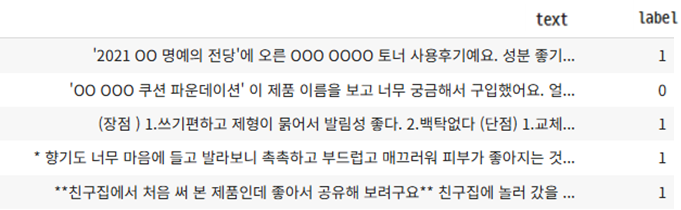

In [15]:
df_gb = df.groupby('text')['label'].mean().reset_index()
display(df_gb.head(3))

df_gb['label'] = np.where(df_gb['label']>=0.5, 1, 0)
display(df_gb.head(3))

,text,label
0,'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기...,0.857143
1,'2022 대한민국소비자대상' 수상을 축하하며 오랜만에 써 본 OO OOO 로션 사...,0.500000
2,'OO OOO 쿠션 파운데이션' 이 제품 이름을 보고 너무 궁금해서 구입했어요. 얼...,0.400000


,text,label
0,'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기...,1
1,'2022 대한민국소비자대상' 수상을 축하하며 오랜만에 써 본 OO OOO 로션 사...,1
2,'OO OOO 쿠션 파운데이션' 이 제품 이름을 보고 너무 궁금해서 구입했어요. 얼...,0


### (3) 데이터 불균형 해결하기

* label의 분포 확인하기

<Axes: xlabel='label', ylabel='count'>

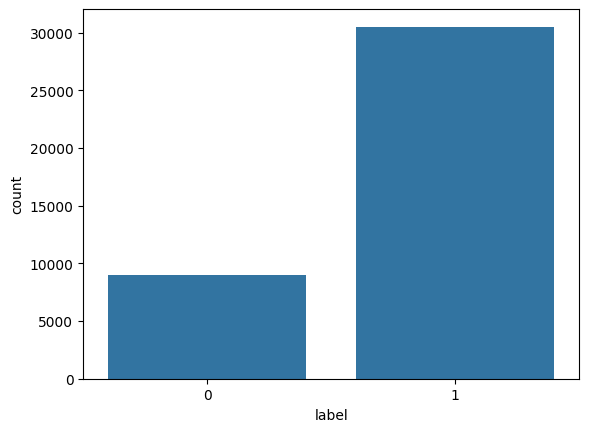

In [16]:
# sns.countplot
sns.countplot(data=df_gb, x='label')

* label이 0과 1인 인 경우 각각 샘플링 2000건씩
    * 더 많이 할 수도 있지만 학습 시간을 고려


In [17]:
# 데이터 샘플링
# df_1 = df.loc[df['label']==1].sample(2000)
# df_0 = df.loc[df['label']==0].sample(2000)
# data_0 = pd.concat([df_0, df_1], axis=0)

df_0 = df_gb[df_gb['label']==0].sample(2000, random_state=16)
df_1 = df_gb[df_gb['label']==1].sample(2000, random_state=16)

df_s = pd.concat([df_0, df_1], axis=0, ignore_index=True)

display(df_s.head())
display(df_s.tail())

,text,label
0,얼굴에 뾰루지 났을 때 효과가 좋습니다. 꼼꼼히 마사지하고 헹궈내면 깔끔하게 씻기고...,0
1,알로에 제품만 구입하는 편입니다. 가격도 비싸고 구성이 좋지 않았지만 OO알로에 제...,0
2,OOO 멀티밤 떨어지지 않게 꾸준하게 주름관리 하려고 더블세트로 구매했습니다. 가격...,0
3,균일하게 잘 발라지진 않아요. 특히 용량이 적어서 아쉽고 붓도 작아서 자주 덧발라야...,0
4,향이 너무 독한 것 같습니다. 첫 향은 그냥 알코올 냄새라 안 좋아요. 잔향도 너무...,0


,text,label
3995,제가 지금까지 많은 남성 향수를 써 왔지만 그 중에서 제일 좋은 것 같아요!!! 정...,1
3996,무엇보다 가격이 저렴해서 팍팍 쓸 수 있으니 좋아요. 사계절용으로 쓰기 좋고 겨울에...,1
3997,우선 사이즈에 깜놀 가성비갑! 커버력도 좋고요 지속력도 좋아요 배송도 완젼빨라요 O...,1
3998,완전 저렴하게 구매했습니다. 이제 면도할 때 수염이 잘 밀려서 좋은 것 같습니다.,1
3999,이 제품 향을 제대로 알지 못한 채 블라인드 구매했습니다. 여름에 쓰기 너무 좋을 ...,1


<Axes: xlabel='label', ylabel='count'>

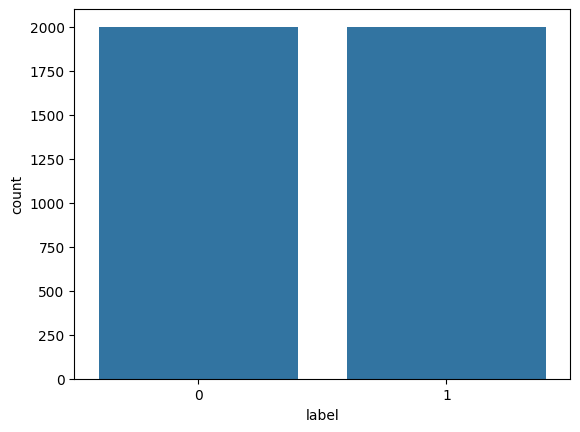

In [18]:
# 데이터 분포 다시 확인
sns.countplot(df_s, x='label')

## 3.데이터 준비② : 데이터 전처리

### (1) Dataset 만들기 : train, val
* train_test_split 함수 이용

In [19]:
train, val = train_test_split(df_s, test_size=0.2, random_state=16)

* 텐서 데이터셋 만들기

In [20]:
train_ts = Dataset.from_pandas(train)
val_ts = Dataset.from_pandas(val)

In [21]:
train_ts[:3]

{'text': ['밥처럼 저한테 꼭 있어야 되는 데일리 필수템입니다. 머릿결 안 좋거나 약하신 분 힘이 없어 날리시는 분들에게 꼭 추천 드려요.',
  '지성 피부에는 안 맞는 것 같습니다. 촉촉하지 않아요. 한방에 바르는 것은 편하지만 보습이 좋지 않아서 안 바르게 됩니다.',
  '유명해서 구매했는데 색깔이 너무 진해서 데일리용으로 쓰기엔 별로네요. 버건디 컬러라 저랑은 안어울리네요. 무엇보다 용기가 얇아서 그립감이 별로인데 휴대하기도 불편해요.'],
 'label': [1, 0, 0],
 '__index_level_0__': [2726, 388, 1415]}

### (2) 토크나이징
* 모델 : "klue/bert-base"

In [22]:
# 모델과 토크나이저 불러오기
model_name="klue/bert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [23]:
# 토큰화 함수 생성 및 작업
def preprocess_function(df_s):
  return tokenizer(df_s['text'], truncation=True, padding=True)

train_ts = train_ts.map(preprocess_function, batched=True)
val_ts = val_ts.map(preprocess_function, batched=True)

Map:   0%|          | 0/3200 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

In [24]:
train_ts[0]

{'text': '밥처럼 저한테 꼭 있어야 되는 데일리 필수템입니다. 머릿결 안 좋거나 약하신 분 힘이 없어 날리시는 분들에게 꼭 추천 드려요.',
 'label': 1,
 '__index_level_0__': 2726,
 'input_ids': [2,
  1127,
  7925,
  1535,
  2470,
  2201,
  677,
  1513,
  13091,
  859,
  2259,
  7660,
  5588,
  2643,
  12190,
  18,
  27770,
  1378,
  1560,
  9253,
  10624,
  2250,
  1175,
  1972,
  2052,
  1415,
  2051,
  10494,
  2067,
  2259,
  1175,
  2031,
  2170,
  2318,
  677,
  4635,
  20469,
  18,
  3,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0

## 4.Fine-Tuning ①
* 일반 파인 튜닝 수행

### (1) 사전학습 모델 준비

In [25]:
# 모델 로드
n = 2
model = AutoModelForSequenceClassification.from_pretrained(model_name,
                                                           num_labels=n,).to(device)

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### (2) 학습 설정

In [26]:
# TrainingArguments 설정
training_args = TrainingArguments(
    output_dir = "./finetune_results",
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate = 2e-5,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size = 32,
    num_train_epochs = 5,
    weight_decay = 0.02,
    load_best_model_at_end = True,
    logging_dir = "./finetune_logs",
    logging_steps = 10,
    report_to = "tensorboard"
)

In [27]:
# Trainer 설정
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset = train_ts,
    eval_dataset = val_ts,
    tokenizer = tokenizer,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=3)],
)

### (3) 학습

In [28]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.197200,0.190692
2,0.106800,0.182672
3,0.127900,0.279508
4,0.011600,0.346584
5,0.031600,0.363727


TrainOutput(global_step=500, training_loss=0.10483824362978339, metrics={'train_runtime': 1139.7067, 'train_samples_per_second': 14.039, 'train_steps_per_second': 0.439, 'total_flos': 2951777152320000.0, 'train_loss': 0.10483824362978339, 'epoch': 5.0})

### (4) 모델 검증평가

In [29]:
eval_results = trainer.evaluate()
print(f"Evaluation results: {eval_results}")

Evaluation results: {'eval_loss': 0.18267163634300232, 'eval_runtime': 11.6993, 'eval_samples_per_second': 68.38, 'eval_steps_per_second': 2.137, 'epoch': 5.0}


In [33]:
text = "사용하기는 좋은데 용량도 애매하고 퍽퍽해요. 그래도 가격 면에서 우수해요"

predicted_class, probabilities = predict(text, model, tokenizer)

label_list = ["부정", "긍정"]  # 클래스 이름 정의

print(f"예측된 클래스: {predicted_class}")
print(f"예측된 클래스 이름: {label_list[predicted_class]}")
print(f"클래스별 확률: {probabilities}")


예측된 클래스: 0
예측된 클래스 이름: 부정
클래스별 확률: tensor([[0.6200, 0.3800]])


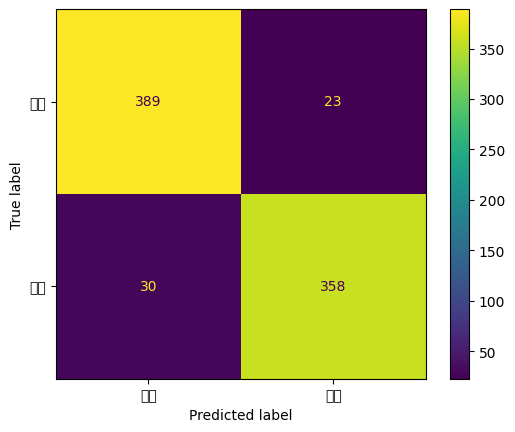

              precision    recall  f1-score   support

          부정       0.93      0.94      0.94       412
          긍정       0.94      0.92      0.93       388

    accuracy                           0.93       800
   macro avg       0.93      0.93      0.93       800
weighted avg       0.93      0.93      0.93       800



In [34]:
pred, prod = evaluate(val_ts, model, device, tokenizer)

from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix(val_ts['label'], pred), display_labels = label_list)
disp.plot()
plt.show()

print(classification_report(val_ts['label'], pred, target_names = label_list))

## 5.Fine-Tuning②
* LoRA(Low-Rank Adaptation)

### (1) 사전학습 모델 준비
* 위에서 적용한 내용

In [35]:
# 모델 로드
base_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels = n)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### (2) LoRA 구성

In [36]:
for name, module in base_model.named_modules():
    if isinstance(module, torch.nn.Linear):
        print(name)


bert.encoder.layer.0.attention.self.query
bert.encoder.layer.0.attention.self.key
bert.encoder.layer.0.attention.self.value
bert.encoder.layer.0.attention.output.dense
bert.encoder.layer.0.intermediate.dense
bert.encoder.layer.0.output.dense
bert.encoder.layer.1.attention.self.query
bert.encoder.layer.1.attention.self.key
bert.encoder.layer.1.attention.self.value
bert.encoder.layer.1.attention.output.dense
bert.encoder.layer.1.intermediate.dense
bert.encoder.layer.1.output.dense
bert.encoder.layer.2.attention.self.query
bert.encoder.layer.2.attention.self.key
bert.encoder.layer.2.attention.self.value
bert.encoder.layer.2.attention.output.dense
bert.encoder.layer.2.intermediate.dense
bert.encoder.layer.2.output.dense
bert.encoder.layer.3.attention.self.query
bert.encoder.layer.3.attention.self.key
bert.encoder.layer.3.attention.self.value
bert.encoder.layer.3.attention.output.dense
bert.encoder.layer.3.intermediate.dense
bert.encoder.layer.3.output.dense
bert.encoder.layer.4.attention.s

In [37]:
# LoRA 구성 정의
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,  # 시퀀스 분류
    r=8,                         # 랭크 값 (작을수록 파라미터 적음)
    lora_alpha=32,               # 너무 작으면 학습 효과 약하고, 너무 크면 발산 위험
    lora_dropout=0.1,
    target_modules=["query", "value", "key"],  # DistilBERT에서 사용되는 attention 레이어 이름
    bias="none"                 # bias는 학습하지 않음
)

# LoRA 적용 (일부 레이어만 학습)
model = get_peft_model(base_model, lora_config)

### (3) 학습

In [40]:
# TrainingArguments 설정
training_args_lora = TrainingArguments(
    output_dir = "./finetune_results",
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate = 5e-5,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size = 32,
    num_train_epochs = 5,
    weight_decay = 0.02,
    load_best_model_at_end = True,
    logging_dir = "./finetune_logs",
    logging_steps = 10,
    report_to = "tensorboard"
)

# Trainer 설정 (compute_metrics, callbacks 등 필요 시 추가)
trainer_lora = Trainer(
    model=model,
    args=training_args_lora,
    train_dataset = train_ts,
    eval_dataset = val_ts,
    tokenizer = tokenizer,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=3)],
)


In [41]:
# 학습 시작
trainer_lora.train()

Epoch,Training Loss,Validation Loss
1,0.340900,0.296250
2,0.220900,0.227878
3,0.240200,0.220679
4,0.146500,0.217580
5,0.194900,0.217240


TrainOutput(global_step=500, training_loss=0.28431949639320375, metrics={'train_runtime': 795.9577, 'train_samples_per_second': 20.102, 'train_steps_per_second': 0.628, 'total_flos': 2967075928704000.0, 'train_loss': 0.28431949639320375, 'epoch': 5.0})

### (4) 모델 검증평가

In [42]:
eval_results_lora = trainer_lora.evaluate()
print(f"Evaluation results: {eval_results_lora}")

Evaluation results: {'eval_loss': 0.21723979711532593, 'eval_runtime': 12.5275, 'eval_samples_per_second': 63.86, 'eval_steps_per_second': 1.996, 'epoch': 5.0}


In [43]:
text = "사용하기는 좋은데 용량도 애매하고 퍽퍽해요. 그래도 가격 면에서 우수해요"

predicted_class, probabilities = predict(text, model, tokenizer)

label_list = ["부정", "긍정"]  # 클래스 이름 정의

print(f"예측된 클래스: {predicted_class}")
print(f"예측된 클래스 이름: {label_list[predicted_class]}")
print(f"클래스별 확률: {probabilities}")


예측된 클래스: 0
예측된 클래스 이름: 부정
클래스별 확률: tensor([[0.8469, 0.1531]])


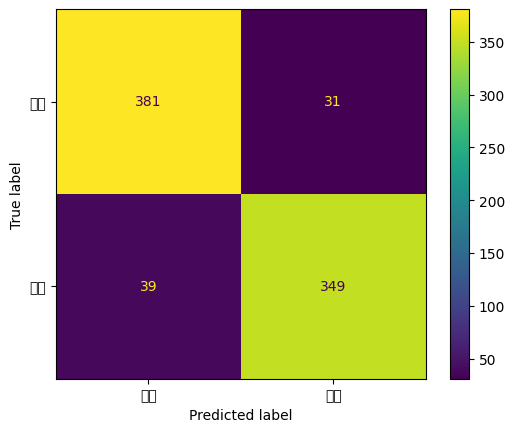

              precision    recall  f1-score   support

          부정       0.91      0.92      0.92       412
          긍정       0.92      0.90      0.91       388

    accuracy                           0.91       800
   macro avg       0.91      0.91      0.91       800
weighted avg       0.91      0.91      0.91       800



In [44]:
pred, prod = evaluate(val_ts, model, device, tokenizer)

from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix(val_ts['label'], pred), display_labels = label_list)
disp.plot()
plt.show()

print(classification_report(val_ts['label'], pred, target_names = label_list))

두 모델 중 더 잘 나온 모델의 하이퍼 파라미터를 gridSearch 해보자

In [46]:
def model_init():
    return AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

In [47]:
trainer = Trainer(
    model_init=model_init,          # 여기서 model_init 사용
    args=training_args,
    train_dataset=train_ts,
    eval_dataset=val_ts,
    tokenizer=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [49]:
# 1라이브러리 설치
!pip install optuna -q

import optuna

# Optuna 하이퍼파라미터 탐색
best_run = trainer.hyperparameter_search(
    direction="maximize",
    backend="optuna",
    n_trials=10,
    hp_space=lambda trial: {
        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True),
        "per_device_train_batch_size": trial.suggest_categorical("per_device_train_batch_size", [16, 32]),
        "num_train_epochs": trial.suggest_categorical("num_train_epochs", [3, 5])
    }
)

print("Best hyperparameters found:")
print(best_run)


[I 2025-10-28 04:29:28,617] A new study created in memory with name: no-name-dc1d0ab1-e5a7-4293-936d-21889d1023ca
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,0.192900,0.175359
2,0.083600,0.195901
3,0.066500,0.243548


[I 2025-10-28 04:39:47,829] Trial 0 finished with value: 0.24354833364486694 and parameters: {'learning_rate': 2.5708752130178172e-05, 'per_device_train_batch_size': 32, 'num_train_epochs': 3}. Best is trial 0 with value: 0.24354833364486694.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,0.218600,0.196840
2,0.141500,0.187339
3,0.150200,0.194647


[I 2025-10-28 04:50:08,302] Trial 1 finished with value: 0.19464658200740814 and parameters: {'learning_rate': 1.0659845735997842e-05, 'per_device_train_batch_size': 32, 'num_train_epochs': 3}. Best is trial 0 with value: 0.24354833364486694.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Epoch,Training Loss,Validation Loss
1,0.220600,0.196931
2,0.132300,0.196349
3,0.154100,0.216783


[I 2025-10-28 06:17:41,016] Trial 8 pruned. 
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,0.210800,0.195106


[I 2025-10-28 06:21:01,213] Trial 9 pruned. 


Best hyperparameters found:
BestRun(run_id='7', objective=0.3715458810329437, hyperparameters={'learning_rate': 2.3167997419552757e-05, 'per_device_train_batch_size': 16, 'num_train_epochs': 5}, run_summary=None)
